# Part 2.2: Cybersecurity – Synthetic Traffic Generation (CICIDS 2017)

### Overview
This section applies GANs to tabular cybersecurity data, focusing on generating synthetic network traffic. Unlike image-based tasks, the model learns structured feature distributions, making this a fundamentally different and more challenging application of GANs.

### Objective
To train a GAN capable of learning the distribution of network traffic features and generating realistic synthetic samples for benign and DDoS attack classes.

### Dataset
- Source: :contentReference[oaicite:0]{index=0}  
- Subset used: **BENIGN and DDoS (Wednesday data)**
- Data Type: Tabular network traffic features

### Tasks Performed
- Loaded and combined dataset files to analyse overall structure  
- Explored feature distributions and class balance  
- Built a GAN to generate synthetic feature vectors (non-image data)  
- Trained the model and monitored generator/discriminator losses  
- Visualised real vs generated data using PCA / t-SNE  
- Evaluated how closely synthetic data matches real data distribution  

### Key Insight
Applying GANs to tabular data introduces challenges such as capturing feature correlations and maintaining realistic distributions, requiring careful evaluation beyond simple visual inspection.


In [1]:
# ============================================================
# CELL 1 — IMPORTS AND GLOBAL STYLING
# ============================================================
"""
Import the libraries needed for CICIDS loading, preprocessing, GAN
training, evaluation, and visualisation. The plotting style matches the
rest of the assignment and avoids blue shades across all saved figures.
"""

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# ============================================================
# CELL 2 — CONFIGURATION AND PROJECT PATHS
# ============================================================
"""
Store the CICIDS settings in one place and build the output structure
from the project root. Because the notebook is inside the Notebook folder,
the project root is taken as the parent directory.
"""

CONFIG_CICIDS = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Dataset
    "data_file_name": "Wednesday-workingHours.pcap_ISCX.csv",

    # Optional row limiting for faster experimentation
    # Keep as None for full filtered data
    "max_rows_per_group": None,

    # Training
    "batch_size": 256,
    "z_dim": 64,
    "g_hidden_dim": 256,
    "d_hidden_dim": 256,
    "epochs": 30,
    "lr": 0.0002,
    "betas": (0.5, 0.999),

    # Evaluation and plotting
    "pca_sample_size": 5000,
    "plot_feature_count": 6,
    "dpi": 300,
    "num_workers": 0
}

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebook" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "Data" / "cicids"
OUTPUTS_ROOT = PROJECT_ROOT / "Outputs"
PART2_OUTPUT_DIR = OUTPUTS_ROOT / "Part2_outputs"
CICIDS_OUTPUT_DIR = PART2_OUTPUT_DIR / "cicids"
CICIDS_PLOTS_DIR = CICIDS_OUTPUT_DIR / "plots"
CICIDS_TABLES_DIR = CICIDS_OUTPUT_DIR / "tables"

CICIDS_DATA_PATH = DATA_DIR / CONFIG_CICIDS["data_file_name"]

for folder in [OUTPUTS_ROOT, PART2_OUTPUT_DIR, CICIDS_OUTPUT_DIR, CICIDS_PLOTS_DIR, CICIDS_TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

device = torch.device(CONFIG_CICIDS["device"])

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"Using device             : {device}")
print(f"Notebook directory       : {NOTEBOOK_DIR}")
print(f"Project root             : {PROJECT_ROOT}")
print(f"CICIDS data path         : {CICIDS_DATA_PATH}")
print(f"CICIDS plots folder      : {CICIDS_PLOTS_DIR}")
print(f"CICIDS tables folder     : {CICIDS_TABLES_DIR}")

Using device             : cpu
Notebook directory       : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Notebook
Project root             : c:\Users\girid\OneDrive\Desktop\Generative modelling case study
CICIDS data path         : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Data\cicids\Wednesday-workingHours.pcap_ISCX.csv
CICIDS plots folder      : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs\cicids\plots
CICIDS tables folder     : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs\cicids\tables


In [3]:
# ============================================================
# CELL 3 — REPRODUCIBILITY
# ============================================================
"""
Fix the random seed so the CICIDS experiment is reproducible. This makes
the training behaviour, synthetic outputs, and final comparisons more
stable and easier to interpret in the report.
"""

def set_seed(seed: int = 42) -> None:
    """
    Fix random seeds for reproducible CICIDS training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG_CICIDS["seed"])

In [4]:
# ============================================================
# CELL 4 — FILE PATH HELPERS
# ============================================================
"""
Create helper functions for saving CICIDS plots and tables into the
correct folders. This keeps the notebook cleaner and makes the outputs
easier to locate during report writing.
"""

def cicids_plot_path(filename: str) -> Path:
    """
    Build the full path for a CICIDS plot file.
    """
    return CICIDS_PLOTS_DIR / filename


def cicids_table_path(filename: str) -> Path:
    """
    Build the full path for a CICIDS table file.
    """
    return CICIDS_TABLES_DIR / filename

In [5]:
# ============================================================
# CELL 5 — LOAD THE WEDNESDAY CICIDS FILE
# ============================================================
"""
Load the Wednesday CICIDS file from the project Data folder and inspect
the basic structure. This is the only required file for the main Part 2.2
task because the brief explicitly asks for Wednesday benign and DoS traffic.
"""

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent
CICIDS_DATA_PATH = PROJECT_ROOT / "Data" / "CICIDS" / "Wednesday-workingHours.pcap_ISCX.csv"

# ------------------------------------------------------------
# Check file exists
# ------------------------------------------------------------
print("Looking for file at:", CICIDS_DATA_PATH)

if not CICIDS_DATA_PATH.exists():
    raise FileNotFoundError(
        f"CICIDS file not found at: {CICIDS_DATA_PATH}\n"
        f"Expected location: {PROJECT_ROOT / 'Data' / 'CICIDS' / 'Wednesday-workingHours.pcap_ISCX.csv'}"
    )

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
raw_cicids_df = pd.read_csv(CICIDS_DATA_PATH, low_memory=False)

# Clean column names (critical for CICIDS)
raw_cicids_df.columns = raw_cicids_df.columns.str.strip()

# ------------------------------------------------------------
# Basic inspection
# ------------------------------------------------------------
print("\n CICIDS Wednesday file loaded successfully.\n")
print("Shape:", raw_cicids_df.shape)
print("First 10 columns:", list(raw_cicids_df.columns[:10]))
print("Last 5 columns:", list(raw_cicids_df.columns[-5:]))

# ------------------------------------------------------------
# Save dataset overview
# ------------------------------------------------------------
dataset_overview = pd.DataFrame({
    "file_name": ["Wednesday-workingHours.pcap_ISCX.csv"],
    "num_rows": [raw_cicids_df.shape[0]],
    "num_columns": [raw_cicids_df.shape[1]]
})

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

overview_path = OUTPUT_DIR / "p2_21_cicids_dataset_overview.csv"
dataset_overview.to_csv(overview_path, index=False)

print("\nDataset overview saved to:", overview_path)
print(dataset_overview)

Looking for file at: c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Data\CICIDS\Wednesday-workingHours.pcap_ISCX.csv

 CICIDS Wednesday file loaded successfully.

Shape: (692703, 79)
First 10 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']
Last 5 columns: ['Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label']

Dataset overview saved to: c:\Users\girid\OneDrive\Desktop\Generative modelling case study\outputs\tables\p2_21_cicids_dataset_overview.csv
                              file_name  num_rows  num_columns
0  Wednesday-workingHours.pcap_ISCX.csv    692703           79


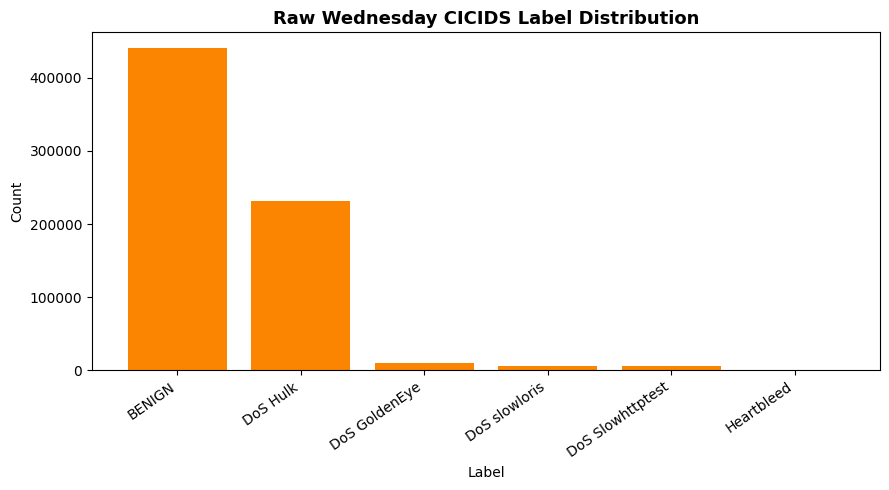

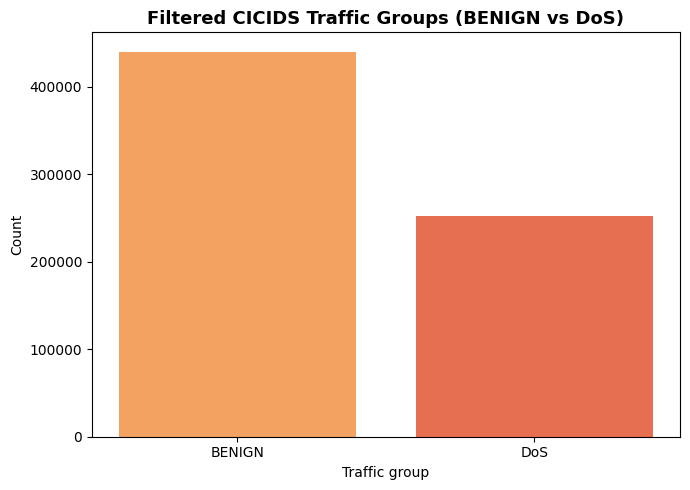

Filtered dataset shape: (692692, 80)
  traffic_group   count
0        BENIGN  440031
1           DoS  252661


In [6]:
# ============================================================
# CELL 6 — LABEL EXPLORATION AND REQUIRED FILTERING
# ============================================================
"""
Inspect the label distribution in the Wednesday file and then filter the
dataset to the traffic types required by the assignment. The retained
rows include BENIGN traffic and the Wednesday DoS attack variants.
"""

if "Label" not in raw_cicids_df.columns:
    raise KeyError("Expected a 'Label' column in the CICIDS dataset, but it was not found.")

raw_label_counts = raw_cicids_df["Label"].astype(str).str.strip().value_counts().sort_values(ascending=False)
raw_label_counts_df = raw_label_counts.reset_index()
raw_label_counts_df.columns = ["label", "count"]
raw_label_counts_df.to_csv(cicids_table_path("p2_22_cicids_raw_label_counts.csv"), index=False)

plt.figure(figsize=(9, 5))
plt.bar(raw_label_counts_df["label"], raw_label_counts_df["count"], color="#FB8500")
plt.title("Raw Wednesday CICIDS Label Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(cicids_plot_path("p2_21_cicids_raw_label_distribution.png"), dpi=CONFIG_CICIDS["dpi"], bbox_inches="tight")
plt.show()

# Keep only BENIGN and labels containing DoS or DDoS
label_series = raw_cicids_df["Label"].astype(str).str.strip()
keep_mask = (label_series == "BENIGN") | label_series.str.contains("DoS|DDoS", case=False, regex=True)

cicids_df = raw_cicids_df.loc[keep_mask].copy()

# Create a broad group column for analysis only
cicids_df["Traffic_Group"] = np.where(
    cicids_df["Label"].astype(str).str.strip() == "BENIGN",
    "BENIGN",
    "DoS"
)

filtered_group_counts = cicids_df["Traffic_Group"].value_counts().sort_index()
filtered_group_counts_df = filtered_group_counts.reset_index()
filtered_group_counts_df.columns = ["traffic_group", "count"]
filtered_group_counts_df.to_csv(cicids_table_path("p2_23_cicids_filtered_group_counts.csv"), index=False)

plt.figure(figsize=(7, 5))
plt.bar(filtered_group_counts_df["traffic_group"], filtered_group_counts_df["count"], color=["#F4A261", "#E76F51"])
plt.title("Filtered CICIDS Traffic Groups (BENIGN vs DoS)", fontsize=13, fontweight="bold")
plt.xlabel("Traffic group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(cicids_plot_path("p2_22_cicids_filtered_group_distribution.png"), dpi=CONFIG_CICIDS["dpi"], bbox_inches="tight")
plt.show()

print("Filtered dataset shape:", cicids_df.shape)
print(filtered_group_counts_df)

In [7]:
# ============================================================
# CELL 7 — PREPROCESSING AND CLEANING
# ============================================================
"""
Clean the filtered CICIDS data and prepare the numeric features for GAN
training. This step removes unusable values, drops non-feature columns,
and standardises the remaining variables for stable optimisation.
"""

# Drop obvious non-feature columns if present
columns_to_drop_if_present = ["Label", "Traffic_Group", "Flow ID", "Source IP", "Destination IP", "Timestamp"]
feature_df = cicids_df.drop(columns=[col for col in columns_to_drop_if_present if col in cicids_df.columns]).copy()

# Keep only numeric columns
feature_df = feature_df.select_dtypes(include=[np.number]).copy()

# Replace inf values with NaN, then drop rows with missing values
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

rows_before_dropna = len(feature_df)
feature_df = feature_df.dropna(axis=0)
rows_after_dropna = len(feature_df)

# Align the cleaned features with the cleaned labels/groups
aligned_cicids_df = cicids_df.loc[feature_df.index].copy()

# Drop zero-variance columns
std_series = feature_df.std(axis=0)
non_constant_columns = std_series[std_series > 0].index.tolist()
feature_df = feature_df[non_constant_columns].copy()

# Optional speed control for very large filtered data
if CONFIG_CICIDS["max_rows_per_group"] is not None:
    sampled_frames = []
    for group_name, group_df in aligned_cicids_df.groupby("Traffic_Group"):
        sampled_idx = group_df.sample(
            n=min(CONFIG_CICIDS["max_rows_per_group"], len(group_df)),
            random_state=CONFIG_CICIDS["seed"]
        ).index
        sampled_frames.append(sampled_idx)

    sampled_idx = pd.Index(np.concatenate(sampled_frames))
    aligned_cicids_df = aligned_cicids_df.loc[sampled_idx].copy()
    feature_df = feature_df.loc[sampled_idx].copy()

# Standardise features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_df)

preprocessing_summary = pd.DataFrame({
    "item": [
        "rows_before_dropna",
        "rows_after_dropna",
        "rows_used_for_training",
        "num_numeric_features_before_constant_drop",
        "num_numeric_features_after_constant_drop"
    ],
    "value": [
        rows_before_dropna,
        rows_after_dropna,
        feature_df.shape[0],
        len(std_series),
        feature_df.shape[1]
    ]
})

preprocessing_summary.to_csv(cicids_table_path("p2_24_cicids_preprocessing_summary.csv"), index=False)
print(preprocessing_summary)

print("Scaled feature matrix shape:", scaled_features.shape)
print("Example feature columns:", feature_df.columns[:10].tolist())

                                        item   value
0                         rows_before_dropna  692692
1                          rows_after_dropna  691395
2                     rows_used_for_training  691395
3  num_numeric_features_before_constant_drop      78
4   num_numeric_features_after_constant_drop      68
Scaled feature matrix shape: (691395, 68)
Example feature columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


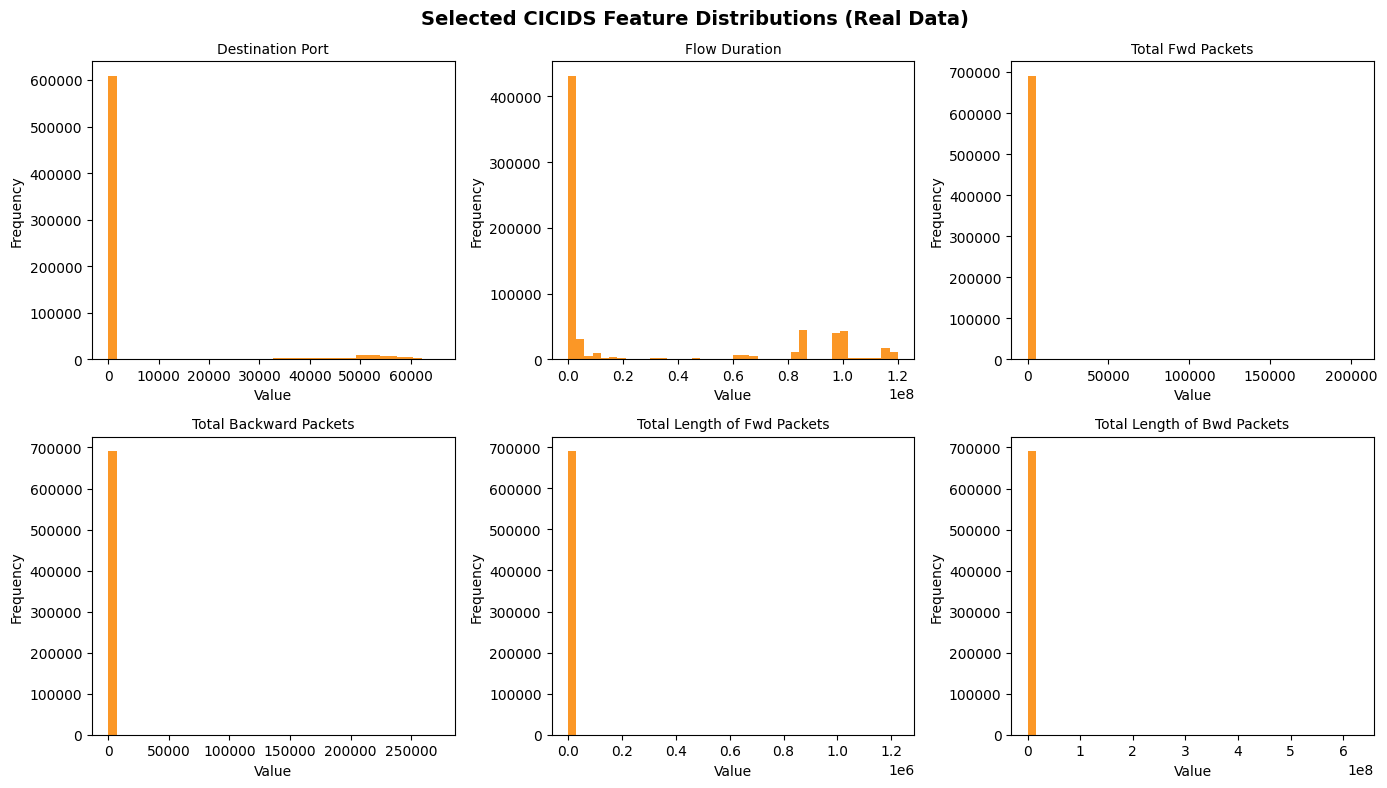

In [8]:
# ============================================================
# CELL 8 — FEATURE DISTRIBUTION SNAPSHOT
# ============================================================
"""
Plot a small set of feature histograms so the reader can see the scale and
shape of a few cleaned CICIDS variables before synthetic data generation.
This also helps support the later comparison against generated samples.
"""

num_features_to_plot = min(CONFIG_CICIDS["plot_feature_count"], feature_df.shape[1])
selected_feature_names = feature_df.columns[:num_features_to_plot].tolist()

fig, axes = plt.subplots(2, int(np.ceil(num_features_to_plot / 2)), figsize=(14, 8))
axes = np.array(axes).reshape(-1)

for i, feature_name in enumerate(selected_feature_names):
    axes[i].hist(feature_df[feature_name].values, bins=40, color="#FB8500", alpha=0.85)
    axes[i].set_title(feature_name, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Selected CICIDS Feature Distributions (Real Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(cicids_plot_path("p2_23_cicids_selected_real_feature_distributions.png"), dpi=CONFIG_CICIDS["dpi"], bbox_inches="tight")
plt.show()

In [9]:
# ============================================================
# CELL 9 — DATASET CLASS AND DATALOADER
# ============================================================
"""
Prepare a PyTorch dataset and dataloader for the standardised CICIDS
feature vectors. Unlike the image tasks, this GAN works directly on
tabular traffic features using fully connected layers.
"""

class CICIDSTabularDataset(Dataset):
    """
    Create a PyTorch dataset for standardised CICIDS feature vectors.
    """
    def __init__(self, features: np.ndarray):
        self.features = torch.tensor(features, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]


tabular_dataset = CICIDSTabularDataset(scaled_features)
pin_memory_flag = torch.cuda.is_available()

train_loader = DataLoader(
    tabular_dataset,
    batch_size=CONFIG_CICIDS["batch_size"],
    shuffle=True,
    num_workers=CONFIG_CICIDS["num_workers"],
    pin_memory=pin_memory_flag,
    drop_last=False
)

sample_feature_batch = next(iter(train_loader))
print("Feature batch shape:", sample_feature_batch.shape)
print("Number of training features:", scaled_features.shape[1])

Feature batch shape: torch.Size([256, 68])
Number of training features: 68


In [10]:
# ============================================================
# CELL 10 — TABULAR GAN MODEL DEFINITIONS
# ============================================================
"""
Define the generator and discriminator for the CICIDS tabular GAN. Since
the data consists of traffic feature vectors rather than images, fully
connected layers are used instead of convolutional layers.
"""

class CICIDSGenerator(nn.Module):
    """
    Build the generator that maps latent noise to synthetic feature vectors.
    """
    def __init__(self, z_dim: int, output_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class CICIDSDiscriminator(nn.Module):
    """
    Build the discriminator that predicts whether a feature vector is real or fake.
    """
    def __init__(self, input_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def weights_init_linear(module):
    """
    Apply a simple weight initialisation for linear layers.
    """
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

In [11]:
# ============================================================
# CELL 11 — TRAINING AND EVALUATION HELPERS
# ============================================================
"""
Create helper functions for latent sampling, loss plotting, PCA plotting,
and basic real-vs-generated feature comparison. These support both the
training analysis and the final report discussion.
"""

def sample_latent(batch_size: int, z_dim: int, device: torch.device) -> torch.Tensor:
    """
    Sample latent noise vectors for the tabular generator.
    """
    return torch.randn(batch_size, z_dim, device=device)


def save_loss_plot(g_losses: list, d_losses: list, filename: str) -> None:
    """
    Save and display the CICIDS generator and discriminator loss curves.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, color="#D81B60", linewidth=2.2, label="Generator Loss")
    plt.plot(d_losses, color="#F4B400", linewidth=2.2, label="Discriminator Loss")
    plt.title("CICIDS Tabular GAN Loss Curves", fontsize=13, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(cicids_plot_path(filename), dpi=CONFIG_CICIDS["dpi"], bbox_inches="tight")
    plt.show()


def save_pca_comparison_plot(real_features: np.ndarray, fake_features: np.ndarray, filename: str) -> None:
    """
    Save and display a PCA plot comparing real and generated feature vectors.
    """
    max_points = CONFIG_CICIDS["pca_sample_size"]

    real_idx = np.random.choice(len(real_features), size=min(max_points, len(real_features)), replace=False)
    fake_idx = np.random.choice(len(fake_features), size=min(max_points, len(fake_features)), replace=False)

    real_sample = real_features[real_idx]
    fake_sample = fake_features[fake_idx]

    combined = np.vstack([real_sample, fake_sample])
    pca = PCA(n_components=2, random_state=CONFIG_CICIDS["seed"])
    combined_pca = pca.fit_transform(combined)

    real_pca = combined_pca[:len(real_sample)]
    fake_pca = combined_pca[len(real_sample):]

    plt.figure(figsize=(8, 6))
    plt.scatter(real_pca[:, 0], real_pca[:, 1], s=10, alpha=0.35, color="#F4A261", label="Real")
    plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=10, alpha=0.35, color="#E76F51", label="Generated")
    plt.title("PCA Comparison of Real vs Generated CICIDS Features", fontsize=13, fontweight="bold")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(cicids_plot_path(filename), dpi=CONFIG_CICIDS["dpi"], bbox_inches="tight")
    plt.show()


def feature_comparison_table(real_df: pd.DataFrame, fake_df: pd.DataFrame, feature_names: list) -> pd.DataFrame:
    """
    Compare selected real and generated features using mean and standard deviation.
    """
    rows = []

    for feature_name in feature_names:
        rows.append({
            "feature": feature_name,
            "real_mean": real_df[feature_name].mean(),
            "generated_mean": fake_df[feature_name].mean(),
            "absolute_mean_difference": abs(real_df[feature_name].mean() - fake_df[feature_name].mean()),
            "real_std": real_df[feature_name].std(),
            "generated_std": fake_df[feature_name].std(),
            "absolute_std_difference": abs(real_df[feature_name].std() - fake_df[feature_name].std())
        })

    return pd.DataFrame(rows)

In [12]:
# ============================================================
# CELL 12 — INITIALISE MODELS, OPTIMISERS, AND TRAINING OBJECTS
# ============================================================
"""
Initialise the CICIDS tabular GAN, apply weight initialisation, and
prepare the optimisers and loss function. The generator output size is
set to match the number of cleaned CICIDS features.
"""

input_dim = scaled_features.shape[1]

generator = CICIDSGenerator(
    z_dim=CONFIG_CICIDS["z_dim"],
    output_dim=input_dim,
    hidden_dim=CONFIG_CICIDS["g_hidden_dim"]
).to(device)

discriminator = CICIDSDiscriminator(
    input_dim=input_dim,
    hidden_dim=CONFIG_CICIDS["d_hidden_dim"]
).to(device)

generator.apply(weights_init_linear)
discriminator.apply(weights_init_linear)

criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=CONFIG_CICIDS["lr"], betas=CONFIG_CICIDS["betas"])
optimizer_d = optim.Adam(discriminator.parameters(), lr=CONFIG_CICIDS["lr"], betas=CONFIG_CICIDS["betas"])

g_losses = []
d_losses = []

print("Generator output dimension:", input_dim)

Generator output dimension: 68


In [13]:
# ============================================================
# CELL 13 — TABULAR GAN TRAINING LOOP
# ============================================================
"""
Train the CICIDS tabular GAN and record the generator and discriminator
losses over time. This loop is kept efficient and avoids unnecessary
plot rendering during training to keep the notebook responsive.
"""

for epoch in range(CONFIG_CICIDS["epochs"]):
    generator.train()
    discriminator.train()

    g_epoch_loss = 0.0
    d_epoch_loss = 0.0

    for real_batch in train_loader:
        real_batch = real_batch.to(device, non_blocking=True)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train discriminator
        # -------------------------
        discriminator.zero_grad(set_to_none=True)

        real_output = discriminator(real_batch)
        d_loss_real = criterion(real_output, real_labels)

        noise = sample_latent(batch_size, CONFIG_CICIDS["z_dim"], device)
        fake_batch = generator(noise)
        fake_output = discriminator(fake_batch.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        # -------------------------
        # Train generator
        # -------------------------
        generator.zero_grad(set_to_none=True)

        noise = sample_latent(batch_size, CONFIG_CICIDS["z_dim"], device)
        fake_batch = generator(noise)
        fake_output = discriminator(fake_batch)

        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        optimizer_g.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()

    g_losses.append(g_epoch_loss / len(train_loader))
    d_losses.append(d_epoch_loss / len(train_loader))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1:>2}/{CONFIG_CICIDS['epochs']}] "
            f"| D Loss: {d_losses[-1]:.4f} "
            f"| G Loss: {g_losses[-1]:.4f}"
        )

training_history_cicids = pd.DataFrame({
    "epoch": np.arange(1, CONFIG_CICIDS["epochs"] + 1),
    "generator_loss": g_losses,
    "discriminator_loss": d_losses
})
training_history_cicids.to_csv(cicids_table_path("p2_25_cicids_training_history.csv"), index=False)

print("CICIDS GAN training complete.")

Epoch [ 1/30] | D Loss: 0.8508 | G Loss: 1.5309
Epoch [ 5/30] | D Loss: 0.4835 | G Loss: 2.7882
Epoch [10/30] | D Loss: 0.5752 | G Loss: 2.5065
Epoch [15/30] | D Loss: 0.5598 | G Loss: 2.4496
Epoch [20/30] | D Loss: 0.5470 | G Loss: 2.3348
Epoch [25/30] | D Loss: 0.5260 | G Loss: 2.2203
Epoch [30/30] | D Loss: 0.5485 | G Loss: 2.2616
CICIDS GAN training complete.


In [14]:
# ============================================================
# CELL 14 — GENERATE SYNTHETIC FEATURE VECTORS
# ============================================================
"""
Generate synthetic CICIDS feature vectors using the trained generator and
map them back to the original feature scale. These synthetic samples are
then used for PCA analysis and feature-wise comparison against real data.
"""

generator.eval()
with torch.no_grad():
    synthetic_scaled = []
    remaining = len(scaled_features)

    while remaining > 0:
        current_batch = min(CONFIG_CICIDS["batch_size"], remaining)
        z = sample_latent(current_batch, CONFIG_CICIDS["z_dim"], device)
        fake_batch = generator(z).cpu().numpy()
        synthetic_scaled.append(fake_batch)
        remaining -= current_batch

synthetic_scaled = np.vstack(synthetic_scaled)
synthetic_original_scale = scaler.inverse_transform(synthetic_scaled)

synthetic_feature_df = pd.DataFrame(synthetic_original_scale, columns=feature_df.columns)

print("Synthetic scaled shape:", synthetic_scaled.shape)
print("Synthetic original-scale shape:", synthetic_feature_df.shape)
synthetic_feature_df.head()

Synthetic scaled shape: (691395, 68)
Synthetic original-scale shape: (691395, 68)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-56.924656,221392.187500,2.870233,0.819910,56.435352,-463.911102,43.118855,42.777618,42.623489,-0.665863,...,1.178436,20.107834,1793.259277,-274.826263,1422.871338,-3298.353027,-119061.890625,5340.393555,-49631.277344,191578.453125
1,-110.053558,19670.193359,2.998853,1.044474,0.122118,4170.622070,28.695669,32.121861,30.707060,-1.989266,...,0.714362,19.966957,-1275.451660,-2426.962891,3998.793213,-3703.009277,-852839.875000,60.768375,-714235.250000,-403565.562500
2,76.845856,-344645.812500,1.546722,-0.381664,48.514088,2001.679688,42.144398,42.768269,42.008972,-2.830330,...,0.649657,20.239815,1653.095215,386.076080,6793.090332,-3865.204590,-464747.875000,-1481.544067,-521961.281250,-260975.546875
3,-107.748383,-194485.812500,2.509076,0.665698,18.397753,1445.913086,32.050724,34.104622,33.106888,-1.399208,...,1.051219,20.077305,1373.462402,-494.822357,1613.761963,-5595.876465,-611545.875000,-834.856628,-619507.250000,-214297.546875
4,40.527493,-148453.812500,2.024021,0.757361,62.453449,3559.346680,57.776997,55.506363,55.675365,-0.244110,...,0.267238,20.062382,1214.103027,-29.091896,1108.402588,-2448.415527,-284781.875000,-12557.106445,-124259.273438,161430.453125


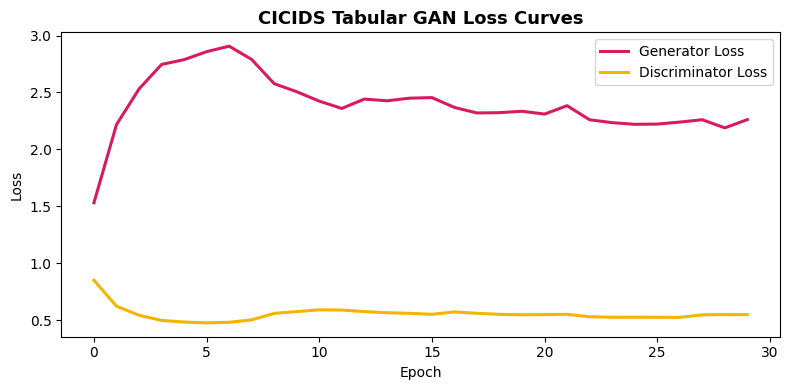

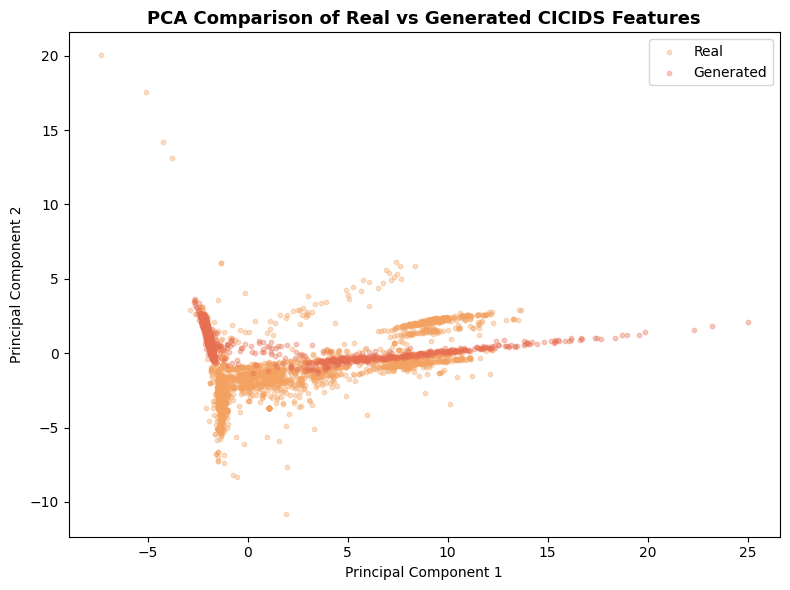

In [15]:
# ============================================================
# CELL 15 — LOSS CURVES AND PCA COMPARISON
# ============================================================
"""
Save and display the main training and comparison plots for Part 2.2.
The loss curve shows training behaviour, while the PCA plot shows how
closely the generated traffic aligns with the real data distribution.
"""

save_loss_plot(
    g_losses=g_losses,
    d_losses=d_losses,
    filename="p2_24_cicids_loss_curves.png"
)

save_pca_comparison_plot(
    real_features=scaled_features,
    fake_features=synthetic_scaled,
    filename="p2_25_cicids_pca_real_vs_generated.png"
)

In [16]:
# ============================================================
# CELL 16 — FEATURE-WISE COMPARISON TABLE
# ============================================================
"""
Create a compact feature comparison table for a small set of CICIDS
variables. This supports the quantitative discussion by showing how
closely the generated traffic matches the real feature statistics.
"""

selected_comparison_features = feature_df.columns[:min(CONFIG_CICIDS["plot_feature_count"], feature_df.shape[1])].tolist()

feature_stats_comparison = feature_comparison_table(
    real_df=feature_df,
    fake_df=synthetic_feature_df,
    feature_names=selected_comparison_features
)

feature_stats_comparison.to_csv(cicids_table_path("p2_26_cicids_feature_stats_comparison.csv"), index=False)
print(feature_stats_comparison)

                       feature     real_mean  generated_mean  \
0             Destination Port  5.683204e+03   -1.016385e+02   
1                Flow Duration  2.805289e+07    7.156604e+06   
2            Total Fwd Packets  9.529764e+00    3.914505e+00   
3       Total Backward Packets  1.020294e+01    2.648532e+00   
4  Total Length of Fwd Packets  5.559394e+02    5.944357e+01   
5  Total Length of Bwd Packets  1.691283e+04    6.449935e+03   

   absolute_mean_difference      real_std  generated_std  \
0              5.784842e+03  1.572245e+04   5.624540e+02   
1              2.089629e+07  4.278861e+07   2.567530e+07   
2              5.615259e+00  7.478295e+02   6.236707e+00   
3              7.554404e+00  9.851045e+02   7.817595e+00   
4              4.964958e+02  6.169245e+03   9.905331e+01   
5              1.046290e+04  2.243096e+06   1.730952e+04   

   absolute_std_difference  
0             1.516000e+04  
1             1.711331e+07  
2             7.415928e+02  
3             

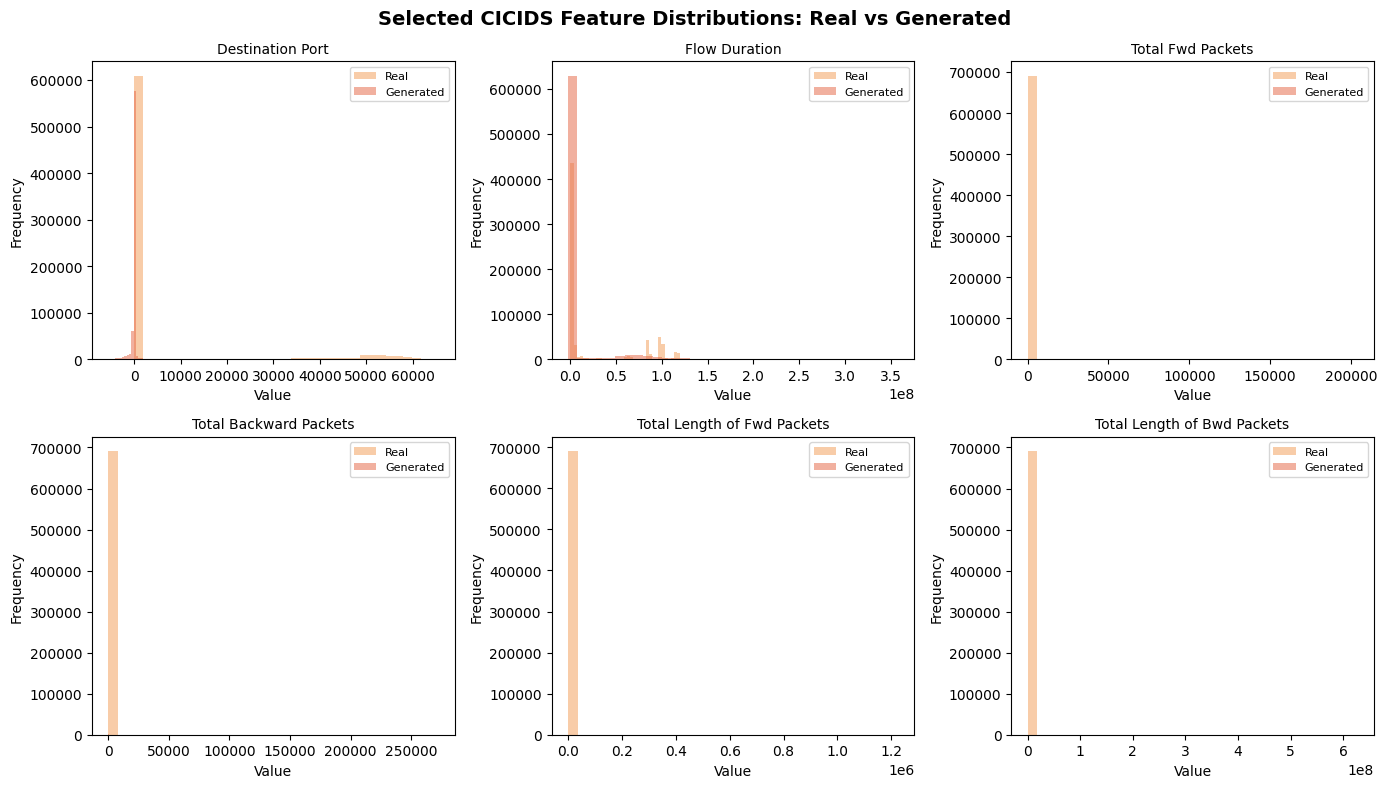

In [17]:
# ============================================================
# CELL 17 — REAL VS GENERATED FEATURE HISTOGRAMS
# ============================================================
"""
Plot a small set of real-versus-generated feature histograms to support
the visual evaluation of distribution matching. These plots help show
whether the GAN has captured the broad shape of key traffic features.
"""

num_features_to_plot = len(selected_comparison_features)

fig, axes = plt.subplots(2, int(np.ceil(num_features_to_plot / 2)), figsize=(14, 8))
axes = np.array(axes).reshape(-1)

for i, feature_name in enumerate(selected_comparison_features):
    axes[i].hist(feature_df[feature_name].values, bins=35, alpha=0.55, color="#F4A261", label="Real")
    axes[i].hist(synthetic_feature_df[feature_name].values, bins=35, alpha=0.55, color="#E76F51", label="Generated")
    axes[i].set_title(feature_name, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(frameon=True, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Selected CICIDS Feature Distributions: Real vs Generated", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(cicids_plot_path("p2_26_cicids_real_vs_generated_feature_histograms.png"), dpi=CONFIG_CICIDS["dpi"], bbox_inches="tight")
plt.show()

In [18]:
# ============================================================
# CELL 18 — COMPACT EXPERIMENT SUMMARY TABLE
# ============================================================
"""
Create one compact summary table with the final CICIDS settings and main
results. This gives a clean numerical record of the experiment without
overcrowding the report with too many separate tables.
"""

group_counts_after_cleaning = aligned_cicids_df["Traffic_Group"].value_counts().sort_index()

cicids_summary = pd.DataFrame({
    "item": [
        "rows_used_for_training",
        "num_features_used",
        "benign_rows_used",
        "dos_rows_used",
        "epochs",
        "batch_size",
        "latent_dim",
        "final_generator_loss",
        "final_discriminator_loss",
        "pca_sample_size",
        "device_used"
    ],
    "value": [
        feature_df.shape[0],
        feature_df.shape[1],
        int(group_counts_after_cleaning.get("BENIGN", 0)),
        int(group_counts_after_cleaning.get("DoS", 0)),
        CONFIG_CICIDS["epochs"],
        CONFIG_CICIDS["batch_size"],
        CONFIG_CICIDS["z_dim"],
        g_losses[-1],
        d_losses[-1],
        min(CONFIG_CICIDS["pca_sample_size"], len(feature_df)),
        str(device)
    ]
})

cicids_summary.to_csv(cicids_table_path("p2_27_cicids_experiment_summary.csv"), index=False)
print(cicids_summary)

                        item     value
0     rows_used_for_training    691395
1          num_features_used        68
2           benign_rows_used    439683
3              dos_rows_used    251712
4                     epochs        30
5                 batch_size       256
6                 latent_dim        64
7       final_generator_loss  2.261579
8   final_discriminator_loss  0.548451
9            pca_sample_size      5000
10               device_used       cpu
